In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df_main = pd.read_csv('C:\\Users\\MONJYEEMAN\\Documents\\Programming\\ML Project\\MechAssist\\data\\module1\\Material Selection\\Data.csv')
df_use = pd.read_csv('C:\\Users\\MONJYEEMAN\\Documents\\Programming\\ML Project\\MechAssist\\data\\module1\\Material Selection\\material.csv')

In [29]:
df_main.shape

(1552, 15)

In [30]:
df_main.columns

Index(['Std', 'ID', 'Material', 'Heat treatment', 'Su', 'Sy', 'A5', 'Bhn', 'E',
       'G', 'mu', 'Ro', 'pH', 'Desc', 'HV'],
      dtype='str')

In [31]:
df_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Std             1552 non-null   str    
 1   ID              1552 non-null   str    
 2   Material        1552 non-null   str    
 3   Heat treatment  802 non-null    str    
 4   Su              1552 non-null   int64  
 5   Sy              1552 non-null   str    
 6   A5              1346 non-null   float64
 7   Bhn             463 non-null    float64
 8   E               1552 non-null   int64  
 9   G               1552 non-null   int64  
 10  mu              1552 non-null   float64
 11  Ro              1552 non-null   int64  
 12  pH              193 non-null    float64
 13  Desc            981 non-null    str    
 14  HV              165 non-null    float64
dtypes: float64(5), int64(4), str(6)
memory usage: 182.0 KB


In [32]:
df_use.columns

Index(['Material', 'Su', 'Sy', 'E', 'G', 'mu', 'Ro', 'Use'], dtype='str')

In [33]:
df_use.shape

(1552, 8)

In [34]:
df_use['Use'].value_counts()

Use
False    1417
True      135
Name: count, dtype: int64

In [35]:
df_main[df_use['Use'] == True]['Desc'].value_counts()

Desc
Structural steel                                                                       46
Heat-resistant steel                                                                   18
Case-hardening steel                                                                    9
Heat-treatment steel                                                                    9
Carbon cast steel                                                                       8
Carbon structural quality steel                                                         8
Free-cutting steel                                                                      6
Carbon structural steel                                                                 6
Stainless steel                                                                         3
Heat-resisting stainless steel                                                          1
Alloy cast steel                                                                        1
Heat-

In [36]:
df_main['Desc'].value_counts()

Desc
Heat-treatment steel                                                                                                105
Structural steel                                                                                                    104
Stainless steel                                                                                                      93
Carbon cast steel                                                                                                    64
Heat-resistant steel                                                                                                 58
                                                                                                                   ... 
Corrosion-resistant, heat-resistant and high-temperature steel, tempering at 640-680 C                                1
Corrosion-resistant, heat-resistant and high-temperature steel, tempering at 540-580 C                                1
Corrosion-resistant, heat-resistant

In [37]:
df_main['Desc'].value_counts().head(20)

Desc
Heat-treatment steel                                                                      105
Structural steel                                                                          104
Stainless steel                                                                            93
Carbon cast steel                                                                          64
Heat-resistant steel                                                                       58
stainless                                                                                  51
Carbon structural quality steel                                                            51
Structural alloy steel                                                                     46
Grey cast iron                                                                             40
Case-hardening steel                                                                       37
Nodular cast iron                                      

In [38]:
df_main[['Su', 'Sy', 'A5', 'Bhn', 'E', 'G', 'mu', 'Ro']].describe()

,Su,A5,Bhn,E,G,mu,Ro
count,1552.000000,1346.000000,463.000000,1552.000000,1552.000000,1552.000000,1552.000000
mean,572.753222,19.329421,177.138229,164571.520619,85598.840206,0.302977,6929.843428
std,326.834927,12.422004,113.508044,56135.405867,125326.800138,0.024590,2115.171710
min,69.000000,0.500000,19.000000,73000.000000,26000.000000,0.200000,1750.000000
25%,340.000000,11.000000,78.000000,105000.000000,40000.000000,0.300000,7160.000000
50%,500.000000,16.000000,170.000000,206000.000000,79000.000000,0.300000,7860.000000
75%,705.000000,24.375000,229.000000,206000.000000,80000.000000,0.320000,7860.000000
max,2220.000000,70.000000,627.000000,219000.000000,769000.000000,0.350000,8930.000000


In [39]:
df_main['Sy'] = pd.to_numeric(df_main['Sy'], errors='coerce')
df_main['Sy'].dtype

dtype('float64')

In [40]:
type(df_main)

pandas.DataFrame

In [41]:
df_main = df_main.drop(columns=['HV', 'pH', 'ID', 'Std', 'Heat treatment'])
df_main.columns

Index(['Material', 'Su', 'Sy', 'A5', 'Bhn', 'E', 'G', 'mu', 'Ro', 'Desc'], dtype='str')

In [42]:
df_main['A5'] = df_main['A5'].fillna(df_main['A5'].median())
df_main['A5'].isnull().sum()

np.int64(0)

In [43]:
df_main.isnull().sum()

Material       0
Su             0
Sy             8
A5             0
Bhn         1089
E              0
G              0
mu             0
Ro             0
Desc         571
dtype: int64

In [44]:
df_main['Sy'] = df_main['Sy'].fillna(df_main['Sy'].median())
df_main.isnull().sum()

Material       0
Su             0
Sy             0
A5             0
Bhn         1089
E              0
G              0
mu             0
Ro             0
Desc         571
dtype: int64

In [45]:
from sklearn.preprocessing import StandardScaler

features = ['Su', 'Sy', 'E', 'G', 'mu', 'Ro', 'A5']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_main[features])

X_scaled.shape

(1552, 7)

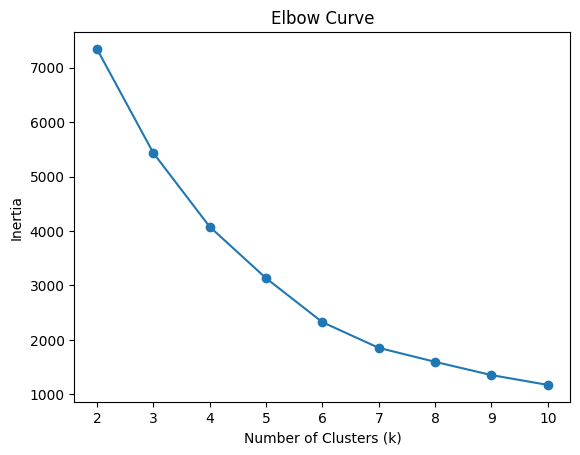

In [46]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [47]:
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
km_final.fit(X_scaled)
df_main['Cluster'] = km_final.labels_
df_main['Cluster'].value_counts()

Cluster
0    678
2    288
5    269
3    156
1    110
4     51
Name: count, dtype: int64

In [48]:
df_main.groupby('Cluster')['Desc'].value_counts().groupby(level=0).head(3)

Cluster  Desc                          
0        Structural steel                  102
         Heat-treatment steel               84
         Carbon cast steel                  56
1        Grey cast iron                     40
         Nodular cast iron                  34
         Malleable cast iron                24
2        Aluminum Alloy Wrought AlCu4Mg      2
         Aluminum Alloy Wrought AlCu2Mg      1
         Aluminum Alloy Wrought AlMg3        1
3        Spring steel                       21
         Heat-treatment steel               21
         Structural alloy steel             20
4        stainless                          51
5        Stainless steel                    53
         Free-drawing steel                  9
         Heat-resistant steel                8
Name: count, dtype: int64

In [49]:
def get_failure_concern(bhn):
    if pd.isna(bhn):
        return "Unknown"
    elif bhn > 300:
        return "Fracture Risk"
    elif bhn > 200:
        return "Fatigue Risk"
    else:
        return "Creep Risk"

In [50]:
def recommend_materials(min_yield, max_density, min_elongation, n=3):
    filtered = df_main[
        (df_main['Sy'] >= min_yield) &
        (df_main['Ro'] <= max_density) &
        (df_main['A5'] >= min_elongation)
    ].copy()
    
    if filtered.empty:
        print("No materials match your requirements.")
        return
    
    filtered = filtered.sort_values(by=['Sy', 'Ro'], ascending=[False, True])
    top = filtered.head(n)
    
    for _, row in top.iterrows():
        concern = get_failure_concern(row['Bhn'])
        print(f"Material: {row['Material']}")
        print(f"  Yield Strength: {row['Sy']} MPa")
        print(f"  Density: {row['Ro']} kg/m³")
        print(f"  Elongation: {row['A5']}%")
        print(f"  Cluster: {row['Cluster']}")
        print(f"  Failure Concern: {concern}")
        print()

In [51]:
recommend_materials(min_yield=300, max_density=8000, min_elongation=10)

Material: Steel SAE 4150
  Yield Strength: 1724.0 MPa
  Density: 7860 kg/m³
  Elongation: 10.0%
  Cluster: 3
  Failure Concern: Fracture Risk

Material: Steel SAE 4340
  Yield Strength: 1675.0 MPa
  Density: 7860 kg/m³
  Elongation: 10.0%
  Cluster: 3
  Failure Concern: Fracture Risk

Material: Steel SAE 8650
  Yield Strength: 1675.0 MPa
  Density: 7860 kg/m³
  Elongation: 10.0%
  Cluster: 3
  Failure Concern: Fracture Risk



In [55]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(km_final, '../models/kmeans_module1.pkl')
joblib.dump(scaler, '../models/scaler_module1.pkl')

['../models/scaler_module1.pkl']

In [61]:
import importlib
import modules.module1_material as m1
importlib.reload(m1)
print(m1.BASE_DIR)
print(m1.DATA_PATH)

c:\Users\MONJYEEMAN\Documents\Programming\ML Project\MechAssist
c:\Users\MONJYEEMAN\Documents\Programming\ML Project\MechAssist\data\module1\Material Selection\Data.csv


In [62]:
importlib.reload(m1)
results = m1.recommend_materials(min_yield=300, max_density=8000, min_elongation=10)
for r in results:
    print(r)

{'Material': 'Steel SAE 4150', 'Yield Strength (MPa)': 1724.0, 'Density (kg/m³)': 7860, 'Elongation (%)': 10.0, 'Cluster': 3, 'Failure Concern': 'Fracture Risk'}
{'Material': 'Steel SAE 4340', 'Yield Strength (MPa)': 1675.0, 'Density (kg/m³)': 7860, 'Elongation (%)': 10.0, 'Cluster': 3, 'Failure Concern': 'Fracture Risk'}
{'Material': 'Steel SAE 8650', 'Yield Strength (MPa)': 1675.0, 'Density (kg/m³)': 7860, 'Elongation (%)': 10.0, 'Cluster': 3, 'Failure Concern': 'Fracture Risk'}
